# K03_04 – Modellvalidierung und Kreuzvalidierung – Dozentenversion vom 23. Mai 2026

Diese Fassung enthält **Musterlösungen und kurze didaktische Hinweise**.

In diesem Notebook geht es um eine zentrale methodische Frage:

> Wie schätzen wir möglichst fair ein, wie gut ein Modell auf neuen Daten funktioniert?

## Lernziele
Nach diesem Notebook können Sie:
- erklären, warum Bewertung auf Trainingsdaten problematisch ist
- `train_test_split` korrekt einsetzen
- den Grundgedanken der Kreuzvalidierung verstehen
- Mittelwert und Streuung von CV-Scores interpretieren

## 1. Ein schlechter Start: Training und Bewertung auf denselben Daten

Wir verwenden den Iris-Datensatz und ein sehr einfaches Modell.


In [2]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import numpy as np

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X, y)
y_pred_train = model.predict(X)

acc_train = accuracy_score(y, y_pred_train)
print(f"Accuracy auf denselben Trainingsdaten: {acc_train:.3f}")

Accuracy auf denselben Trainingsdaten: 1.000


### Beobachtung
Dieser Wert wirkt sehr gut.  
Aber er ist **zu optimistisch**, weil wir das Modell auf denselben Daten bewerten, auf denen es gelernt hat.

### Warum liefert `n_neighbors=1` auf den Trainingsdaten immer 100 %?
Bei `n_neighbors=1` ist der nächste Nachbar eines Trainingspunkts **er selbst** — der Abstand beträgt 0.  
Das Modell „erinnert“ sich an jeden Trainingspunkt exakt und macht deshalb **keinen einzigen Fehler** auf den Trainingsdaten.  
Auf neuen, unbekannten Daten versagt es entsprechend häufiger — ein klassisches Beispiel für **Overfitting**.


## Mini-Übung 1
Warum ist diese Methode keine faire Schätzung für neue, unbekannte Daten?


### Musterlösung / Dozentenhinweis
Diese Methode ist unfair, weil das Modell auf **denselben Daten trainiert und bewertet** wird. Dadurch fällt die Leistung meist **zu optimistisch** aus. Wir erhalten also keine realistische Schätzung dafür, wie gut das Modell auf **neuen, unbekannten Daten** funktioniert.

Didaktischer Kernbegriff: **Generalisierung**.

## 2. Bessere Methode: Train/Test-Split


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
    stratify=y   # sorgt dafür, dass alle Klassen in Train und Test gleich verteilt sind
)

model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train)
y_pred_test = model.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
print(f"Accuracy auf Testdaten: {acc_test:.3f}")

Accuracy auf Testdaten: 0.933


### Merksatz
Die Testdaten sollen das Modell **erst ganz am Ende** sehen.


## 3. Kreuzvalidierung

Ein einzelner Train/Test-Split kann zufällig günstig oder ungünstig sein.  
Deshalb verwenden wir oft **Cross-Validation**.


In [6]:
cv_scores = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X, y,
    cv=5,
    scoring="accuracy"
)

print("Einzelne CV-Scores:", np.round(cv_scores, 3))
print("Mittelwert:", round(cv_scores.mean(), 3))
print("Standardabweichung:", round(cv_scores.std(), 3))


Einzelne CV-Scores: [0.967 1.    0.933 0.967 1.   ]
Mittelwert: 0.973
Standardabweichung: 0.025


## Mini-Übung 2
1. Warum unterscheiden sich die einzelnen Folds?
2. Was sagt der Mittelwert aus?
3. Was sagt die Standardabweichung aus?


### Musterlösung / Dozentenhinweis
1. Die Folds unterscheiden sich, weil jeweils **andere Trainings- und Testaufteilungen** entstehen.
2. Der **Mittelwert** beschreibt die durchschnittliche Modellleistung über alle Folds.
3. Die **Standardabweichung** zeigt, wie stark die Ergebnisse zwischen den Folds schwanken.

Didaktisch wichtig: Nicht nur der Mittelwert zählt, sondern auch die Stabilität der Ergebnisse.

## 4. Vergleich mehrerer Werte für k


In [7]:
results = []

for k in range(1, 16):
    scores = cross_val_score(
        KNeighborsClassifier(n_neighbors=k),
        X, y,
        cv=5,
        scoring="accuracy"
    )
    results.append((k, scores.mean(), scores.std()))

import pandas as pd
df_results = pd.DataFrame(results, columns=["k", "mean_accuracy", "std_accuracy"])
df_results.round(3)


,k,mean_accuracy,std_accuracy
0,1,0.960,0.025
1,2,0.947,0.034
2,3,0.967,0.021
3,4,0.973,0.013
4,5,0.973,0.025
5,6,0.980,0.016
6,7,0.980,0.016
7,8,0.967,0.030
8,9,0.973,0.025
9,10,0.980,0.027


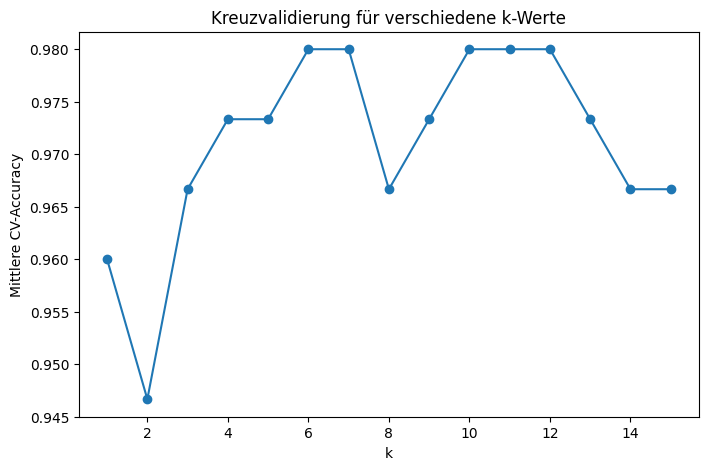

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(df_results["k"], df_results["mean_accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Mittlere CV-Accuracy")
plt.title("Kreuzvalidierung für verschiedene k-Werte")
plt.show()


### Beobachtung
Hier sehen wir, dass Modellleistung vom Hyperparameter `k` abhängt.  
Kreuzvalidierung hilft uns, diese Wahl robuster zu beurteilen.


## Was tun wir mit dem besten k? Das finale Modell

Cross-Validation hat uns gezeigt, welches `k` im Mittel am besten abschneidet.  
Jetzt trainieren wir das **finale Modell** mit diesem `k` auf **allen Daten**.

> **Merksatz:** Cross-Validation bewertet ein *Verfahren* — das finale Modell  
> wird danach separat mit `fit(X, y)` auf allen Daten trainiert.

| Frage | Werkzeug | Ergebnis |
|---|---|---|
| Welches k ist am besten geeignet? | `cross_val_score` in Schleife | Tabelle + Plot |
| Trainiere das einsatzbereite Modell | `model.fit(X, y)` | Trainiertes Modell |


In [9]:
# Bestes k aus dem CV-Vergleich ablesen
bestes_k = int(df_results.loc[df_results["mean_accuracy"].idxmax(), "k"])
print(f"Bestes k laut Cross-Validation: {bestes_k}")
print(f"Mittlere CV-Accuracy: {df_results['mean_accuracy'].max():.3f}")

# Finales Modell auf ALLEN Daten trainieren
final_model = KNeighborsClassifier(n_neighbors=bestes_k)
final_model.fit(X, y)   # kein Split mehr — alle Daten fliessen ins Training

print(f"\nFinales Modell (k={bestes_k}) ist einsatzbereit.")
print("Vorhersage für einen neuen Datenpunkt:")
neuer_punkt = [[5.1, 3.5, 1.4, 0.2]]
klasse = final_model.predict(neuer_punkt)[0]
print(f"  Klasse {klasse} = {iris.target_names[klasse]}")


Bestes k laut Cross-Validation: 6
Mittlere CV-Accuracy: 0.980

Finales Modell (k=6) ist einsatzbereit.
Vorhersage für einen neuen Datenpunkt:
  Klasse 0 = setosa


> **Hinweis:** Da die CV-Schleife zur Wahl von k und das Training des
> finalen Modells auf denselben Daten stattfinden, ist der CV-Score
> eine leicht optimistische Schätzung. Für einen vollständig unabhängigen
> Leistungsnachweis wäre ein äußerer Holdout-Split (Train/Test vor der
> CV-Schleife) erforderlich.

## 5. StratifiedKFold

Bei Klassifikation ist es oft sinnvoll, die Klassenverteilung in den Folds möglichst ähnlich zu halten.


In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,       # Daten vor dem Aufteilen mischen, damit die Reihenfolge keinen Einfluss hat
    random_state=42     # Seed fuer Reproduzierbarkeit
)
scores_strat = cross_val_score(
    KNeighborsClassifier(n_neighbors=5),
    X, y,
    cv=cv,
    scoring="accuracy"
)

print("Scores mit StratifiedKFold:", np.round(scores_strat, 3))
print("Mittelwert:", round(scores_strat.mean(), 3))

Scores mit StratifiedKFold: [1.    0.967 0.933 1.    0.933]
Mittelwert: 0.967


## Mini-Übung 3
Warum ist bei Klassifikationsproblemen eine ähnliche Klassenverteilung in allen Folds oft sinnvoll?


### Musterlösung / Dozentenhinweis
Eine ähnliche Klassenverteilung in allen Folds ist sinnvoll, damit jede Teilaufteilung das Problem **vergleichbar repräsentiert**. Sonst könnte ein Fold zufällig viel mehr oder viel weniger Beispiele einer Klasse enthalten und das Ergebnis verzerren.

Hier kann gut auf **StratifiedKFold** verwiesen werden.

## 6. Zusammenfassung

- Bewertung auf Trainingsdaten ist methodisch ungeeignet
- ein Holdout-Test ist besser
- Kreuzvalidierung ist oft robuster
- wir betrachten dabei nicht nur einen Score, sondern auch seine Streuung
- `StratifiedKFold` sorgt für gleichmäßige Klassenverteilung in allen Folds
- Cross-Validation bewertet ein **Verfahren** — das finale Modell wird danach separat mit `fit(X, y)` auf allen Daten trainiert
